<a href="https://colab.research.google.com/github/SANDULFERNANDO/Stellarx-Diagnostic-System/blob/feature%2FDenseNet-model/densenet_improved_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import random

import numpy as np
import pandas as pd
import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from tensorflow.keras.applications import DenseNet121

from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    CSVLogger
)

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
DATASET_DIR = "/content/drive/MyDrive/dataset"

TRAIN_DIR = os.path.join(
    DATASET_DIR,
    "Train"
)

VAL_DIR = os.path.join(
    DATASET_DIR,
    "Validation"
)

TEST_DIR = os.path.join(
    DATASET_DIR,
    "Test"
)

print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

Train: /content/drive/MyDrive/dataset/Train
Validation: /content/drive/MyDrive/dataset/Validation
Test: /content/drive/MyDrive/dataset/Test


In [ ]:
print("Train exists:", os.path.exists(TRAIN_DIR))
print("Validation exists:", os.path.exists(VAL_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

Train exists: True
Validation exists: True
Test exists: True


In [ ]:
print("Train classes:")
print(os.listdir(TRAIN_DIR))

print("\nValidation classes:")
print(os.listdir(VAL_DIR))

print("\nTest classes:")
print(os.listdir(TEST_DIR))

Train classes:
['Tinea', 'Leishmaniasis', 'Eczema']

Validation classes:
['Tinea', 'Eczema', 'Leishmaniasis']

Test classes:
['Leishmaniasis', 'Eczema', 'Tinea']


In [ ]:
IMG_SIZE = (224, 224)

BATCH_SIZE = 32

NUM_CLASSES = 3

INITIAL_LR = 1e-4

FINE_TUNE_LR = 1e-5

FROZEN_EPOCHS = 15

FINE_TUNE_EPOCHS = 15

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

Found 2688 files belonging to 3 classes.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 574 files belonging to 3 classes.


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 573 files belonging to 3 classes.


In [ ]:
class_names = train_ds.class_names

print("Class names:", class_names)
print("Number of classes:", len(class_names))

Class names: ['Eczema', 'Leishmaniasis', 'Tinea']
Number of classes: 3


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)

test_ds = test_ds.prefetch(
    buffer_size=AUTOTUNE
)

In [ ]:
y_train = []

for images, labels in train_ds:

    labels = np.argmax(
        labels.numpy(),
        axis=1
    )

    y_train.extend(labels)

y_train = np.array(y_train)

In [ ]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    i: weight
    for i, weight in enumerate(
        class_weights_array
    )
}

print("Class weights:")

for i, class_name in enumerate(class_names):

    print(
        f"{class_name}: "
        f"{class_weights[i]:.4f}"
    )

Class weights:
Eczema: 0.8289
Leishmaniasis: 1.7099
Tinea: 0.8273


In [ ]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
inputs = Input(
    shape=(224, 224, 3),
    name="input_image"
)

x = base_model(
    inputs,
    training=False
)

x = GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = Dense(
    512,
    activation="relu",
    name="dense_512"
)(x)

x = Dropout(
    0.4,
    name="dropout_1"
)(x)

x = Dense(
    128,
    activation="relu",
    name="dense_128"
)(x)

x = Dropout(
    0.3,
    name="dropout_2"
)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax",
    name="predictions"
)(x)

model = Model(
    inputs=inputs,
    outputs=outputs,
    name="Improved_DenseNet121"
)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=INITIAL_LR
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy",

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

In [ ]:
model.summary()

Model: "Improved_DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_512 (Dense)               │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,628,355 (29.10 MB)

 Trainable params: 590,851 (2.25 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
checkpoint_stage1 = "/content/drive/MyDrive/DenseNet121_stage1_best.keras"

callbacks_stage1 = [

    ModelCheckpoint(
        checkpoint_stage1,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    CSVLogger(
        "/content/drive/MyDrive/DenseNet121_stage1_log.csv"
    )
]

In [ ]:
history_stage1 = model.fit(
    train_ds,

    validation_data=val_ds,

    epochs=FROZEN_EPOCHS,

    class_weight=class_weights,

    callbacks=callbacks_stage1
)

Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4775 - loss: 2.1677 - precision: 0.4837 - recall: 0.4581
Epoch 1: val_accuracy improved from None to 0.76829, saving model to /content/drive/MyDrive/DenseNet121_stage1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DenseNet121_stage1_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 732s 8s/step - accuracy: 0.5484 - loss: 1.7107 - precision: 0.5597 - recall: 0.5298 - val_accuracy: 0.7683 - val_loss: 0.6036 - val_precision: 0.7852 - val_recall: 0.7387 - learning_rate: 1.0000e-04
Epoch 2/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6682 - loss: 1.0230 - precision: 0.6781 - recall: 0.6438
Epoch 2: val_accuracy did not improve from 0.76829
84/84 ━━━━━━━━━━━━━━━━━━━━ 701s 8s/step - accuracy: 0.6797 - loss: 0.9938 - precision: 0.6935 - recall: 0.6540 - val_accuracy: 0.7230 - val_loss: 0.6207 - val_precision: 0.7575 - val_recall: 0.7021 - learning_rate: 1.0000e-04
Epoch 3/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/ste

In [ ]:
base_model.trainable = True

In [ ]:
total_layers = len(base_model.layers)

print(
    "Total DenseNet121 layers:",
    total_layers
)

Total DenseNet121 layers: 427


In [ ]:
fine_tune_from = int(
    total_layers * 0.70
)

print(
    "Fine-tuning from layer:",
    fine_tune_from
)

Fine-tuning from layer: 298


In [ ]:
for layer in base_model.layers:

    layer.trainable = False

In [ ]:
for layer in base_model.layers[fine_tune_from:]:

    layer.trainable = True

In [ ]:
for layer in base_model.layers:

    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):

        layer.trainable = False

In [ ]:
trainable_count = sum(
    layer.trainable
    for layer in base_model.layers
)

print(
    "Trainable DenseNet layers:",
    trainable_count
)

Trainable DenseNet layers: 92


In [ ]:
1e-5

1e-05

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy",

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

In [ ]:
checkpoint_stage2 = "/content/drive/MyDrive/DenseNet121_finetuned_best.keras"

callbacks_stage2 = [

    ModelCheckpoint(
        checkpoint_stage2,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    CSVLogger(
        "/content/drive/MyDrive/DenseNet121_stage2_log.csv"
    )
]

In [ ]:
history_stage2 = model.fit(
    train_ds,

    validation_data=val_ds,

    epochs=FINE_TUNE_EPOCHS,

    class_weight=class_weights,

    callbacks=callbacks_stage2
)

Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9068 - loss: 0.2634 - precision: 0.9174 - recall: 0.9009
Epoch 1: val_accuracy improved from None to 0.87456, saving model to /content/drive/MyDrive/DenseNet121_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DenseNet121_finetuned_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 855s 10s/step - accuracy: 0.9163 - loss: 0.2446 - precision: 0.9230 - recall: 0.9100 - val_accuracy: 0.8746 - val_loss: 0.3513 - val_precision: 0.8923 - val_recall: 0.8659 - learning_rate: 1.0000e-05
Epoch 2/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9214 - loss: 0.2179 - precision: 0.9302 - recall: 0.9151
Epoch 2: val_accuracy improved from 0.87456 to 0.88153, saving model to /content/drive/MyDrive/DenseNet121_finetuned_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DenseNet121_finetuned_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 819s 10s/step - accuracy: 0.9200 - loss: 0.2255 - precision: 0.9257 - r

In [ ]:
train_acc = (
    history_stage1.history["accuracy"]
    +
    history_stage2.history["accuracy"]
)

val_acc = (
    history_stage1.history["val_accuracy"]
    +
    history_stage2.history["val_accuracy"]
)

train_loss = (
    history_stage1.history["loss"]
    +
    history_stage2.history["loss"]
)

val_loss = (
    history_stage1.history["val_loss"]
    +
    history_stage2.history["val_loss"]
)

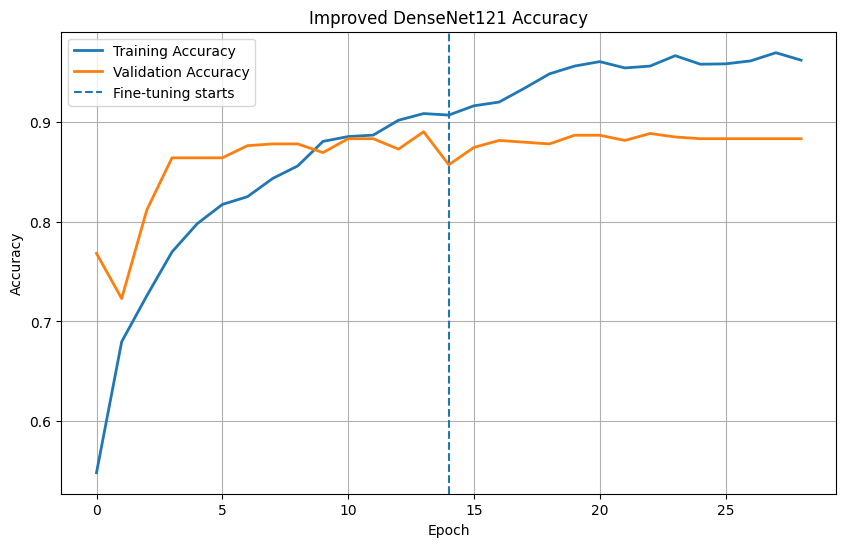

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    train_acc,
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    val_acc,
    label="Validation Accuracy",
    linewidth=2
)

stage2_start = len(
    history_stage1.history["accuracy"]
)

plt.axvline(
    stage2_start - 1,
    linestyle="--",
    label="Fine-tuning starts"
)

plt.title(
    "Improved DenseNet121 Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

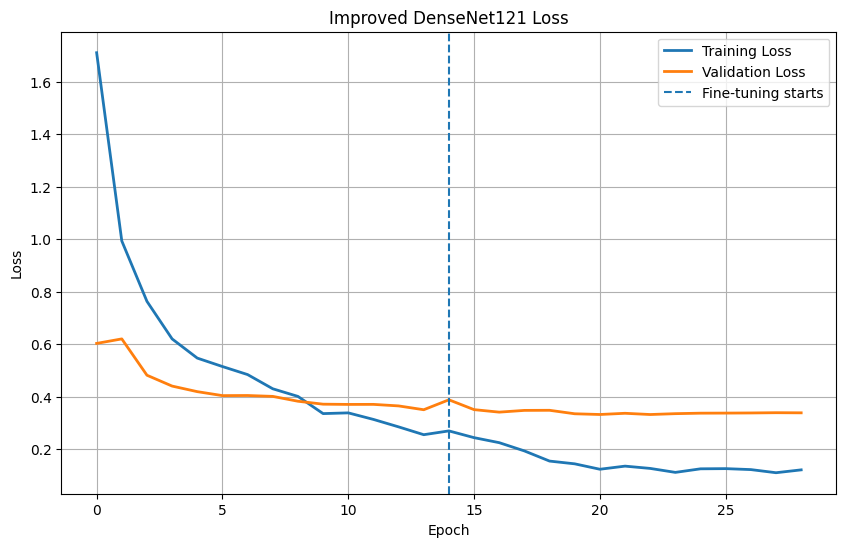

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    train_loss,
    label="Training Loss",
    linewidth=2
)

plt.plot(
    val_loss,
    label="Validation Loss",
    linewidth=2
)

stage2_start = len(
    history_stage1.history["loss"]
)

plt.axvline(
    stage2_start - 1,
    linestyle="--",
    label="Fine-tuning starts"
)

plt.title(
    "Improved DenseNet121 Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
test_results = model.evaluate(
    test_ds,
    verbose=1,
    return_dict=True
)

print("\nFinal Test Results")

for metric, value in test_results.items():

    print(
        f"{metric}: {value:.4f}"
    )

18/18 ━━━━━━━━━━━━━━━━━━━━ 132s 7s/step - accuracy: 0.9372 - loss: 0.2272 - precision: 0.9402 - recall: 0.9337

Final Test Results
accuracy: 0.9372
loss: 0.2272
precision: 0.9402
recall: 0.9337


In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    true_labels = np.argmax(
        labels.numpy(),
        axis=1
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        true_labels
    )

    y_pred.extend(
        predicted_labels
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

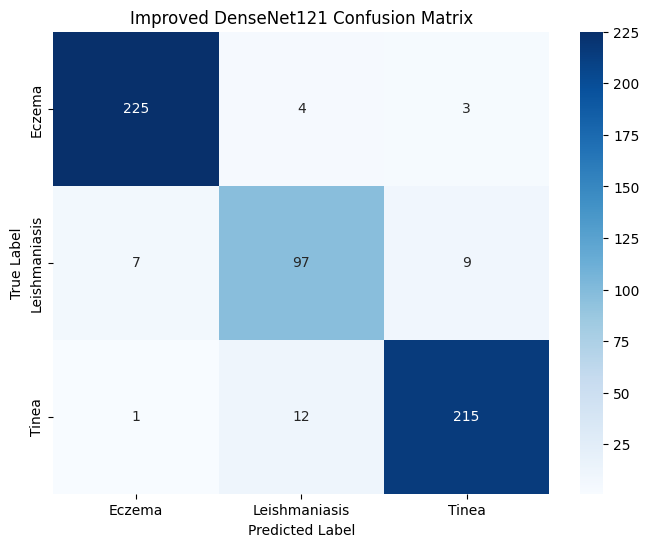

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    "Improved DenseNet121 Confusion Matrix"
)

plt.show()

In [ ]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

               precision    recall  f1-score   support

       Eczema     0.9657    0.9698    0.9677       232
Leishmaniasis     0.8584    0.8584    0.8584       113
        Tinea     0.9471    0.9430    0.9451       228

     accuracy                         0.9372       573
    macro avg     0.9237    0.9237    0.9237       573
 weighted avg     0.9371    0.9372    0.9372       573



In [ ]:
MODEL_PATH = "/content/drive/MyDrive/dataset/DenseNet121_Tinea_improved_Model.keras"

model.save(MODEL_PATH)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 573 files belonging to 3 classes.
